# Amazon US Customer Reviews: Preprocessing & First Distributed Model

This notebook explores the data in the [Amazon US Customer Reviews](https://www.kaggle.com/datasets/cynthiarempel/amazon-us-customer-reviews-dataset) dataset sourced from Kaggle. 

## Setup and Imports

In [1]:
from pyspark.sql import SparkSession, SQLContext
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
from pyspark.sql import SQLContext
from pyspark.sql.functions import col, length, round, expr, sum as spark_sum
from pyspark.ml.feature import Imputer, StringIndexer, VectorAssembler
import builtins
py_round = builtins.round

Matplotlib created a temporary cache directory at /scratch/hkwon2/job_49886773/matplotlib-z9aeydu2 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Spark Session Configuration

Our SDSC Expanse allocation provides 16 total cores and 128 GB total memory. The dataset is 50.68 GB across 37 Parquet files. 

In [2]:
import subprocess, os
USER = os.getenv("USER")
subprocess.run(["mkdir", "-p", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp"])

CompletedProcess(args=['mkdir', '-p', '/expanse/lustre/projects/uci157/hkwon2/spark_tmp'], returncode=0)

In [3]:
spark = SparkSession.builder \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config('spark.executor.instances', 15) \
    .config("spark.executor.cores", "1") \
    .config("spark.sql.shuffle.partitions", "64") \
    .config("spark.local.dir", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp") \
    .config("spark.sql.parquet.columnarReaderBatchSize", "128") \
    .getOrCreate()

### Executor Verification

In [4]:
# Get the active Spark Context, URL, and SQL Context
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"
sqlContext = SQLContext(spark.sparkContext)

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
spd = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
spd['maxMemory_GB'] = (spd['maxMemory'] / (1024**3)).round(2)
spd

/usr/local/spark/python/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,16,4965217075,0,True,4.62


### Current Spark Configuration

In [5]:
print("Executor Instances:", sc.getConf().get("spark.executor.instances"))
print("Executor Memory:", sc.getConf().get("spark.executor.memory"))
print("Driver Memory:", sc.getConf().get("spark.driver.memory"))
print("Executor Cores:", sc.getConf().get("spark.executor.cores"))
print("Total Cores Available:", sc._jsc.sc().defaultParallelism())

Executor Instances: 15
Executor Memory: 8g
Driver Memory: 8g
Executor Cores: 1
Total Cores Available: 16


### Output of preprocessed clean dataset

In [7]:
output_path = "/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews_clean.parquet"
df_clean = spark.read.parquet(output_path)

In [10]:
# View the schema
df_clean.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_headline_length: integer (nullable = true)
 |-- verified_purchase_idx: double (nullable = true)
 |-- category_idx: double (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- review_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- helpfulness_ratio: double (nullable = tr

In [11]:
selected_cols = [
    "review_id",
    "star_rating",
    "review_headline_length",
    "verified_purchase_idx",
    "category_idx",
    "log_helpful_votes",
    "log_total_votes",
    "log_review_length",
    "helpfulness_ratio",
    "label"
]
df_clean_target = df_clean.select(selected_cols)

## 2. PCA Pipeline

### 1. Fitting 

In [12]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
# 5 features that are numerical and might affect the label.
feature_cols = [
    "star_rating",
    "review_headline_length",
    "verified_purchase_idx",
    "category_idx",
    "log_review_length"
]
pca_k = 3 # Number of eigenvector used

In [14]:
# Train / Val / Test split (0.7 / 0.15 / 0.15)
train_df, val_df, test_df = df_clean_target.randomSplit([0.7, 0.15, 0.15], seed=42)

# VectorAssembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features", handleInvalid="skip")

# StandardScaler
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)

# PCA
pca = PCA(k=pca_k, inputCol="scaled_features", outputCol="pca_features")

# LogisticRegression
lr = LogisticRegression(featuresCol="pca_features", labelCol="label", maxIter=20, regParam=0.01)

pipeline = Pipeline(stages=[assembler, scaler, pca, lr])
model    = pipeline.fit(train_df)

train_pred_pca = model.transform(train_df)
val_pred_pca   = model.transform(val_df)
test_pred_pca  = model.transform(test_df)

print(f"Input dimensions : {len(feature_cols)}")
print(f"PCA components   : {pca_k}")
print("Fitted successfully.")

Input dimensions : 5
PCA components   : 3
Fitted successfully.


### 2. Evaluate Your Model

In [15]:
# Evaluate: Train vs Val vs Test performance
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

train_auc_pca = evaluator_auc.evaluate(train_pred_pca)
val_auc_pca   = evaluator_auc.evaluate(val_pred_pca)
test_auc_pca  = evaluator_auc.evaluate(test_pred_pca)
train_f1_pca  = evaluator_f1.evaluate(train_pred_pca)
val_f1_pca    = evaluator_f1.evaluate(val_pred_pca)
test_f1_pca   = evaluator_f1.evaluate(test_pred_pca)

print("=== PCA (k=3) + Logistic Regression ===")
print(f"Train  AUC: {train_auc_pca:.4f} | F1: {train_f1_pca:.4f}")
print(f"Val    AUC: {val_auc_pca:.4f}  | F1: {val_f1_pca:.4f}")
print(f"Test   AUC: {test_auc_pca:.4f}  | F1: {test_f1_pca:.4f}")

=== PCA (k=3) + Logistic Regression ===
Train  AUC: 0.6347 | F1: 0.6065
Val    AUC: 0.6349  | F1: 0.6066
Test   AUC: 0.6347  | F1: 0.6068


### 3. Explained Variance Analysis

In [16]:
# Extract PCA model (stage index 2 from assembler, scaler, pca, lr)
pca_fitted = model.stages[2]

explained_var  = pca_fitted.explainedVariance.toArray()
cumulative_var = np.cumsum(explained_var)

print("Explained Variance per Principal Component:")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.1f}%)  —  Cumulative: {cv*100:.1f}%")

Explained Variance per Principal Component:
  PC1: 0.3107 (31.1%)  —  Cumulative: 31.1%
  PC2: 0.2029 (20.3%)  —  Cumulative: 51.4%
  PC3: 0.1956 (19.6%)  —  Cumulative: 70.9%


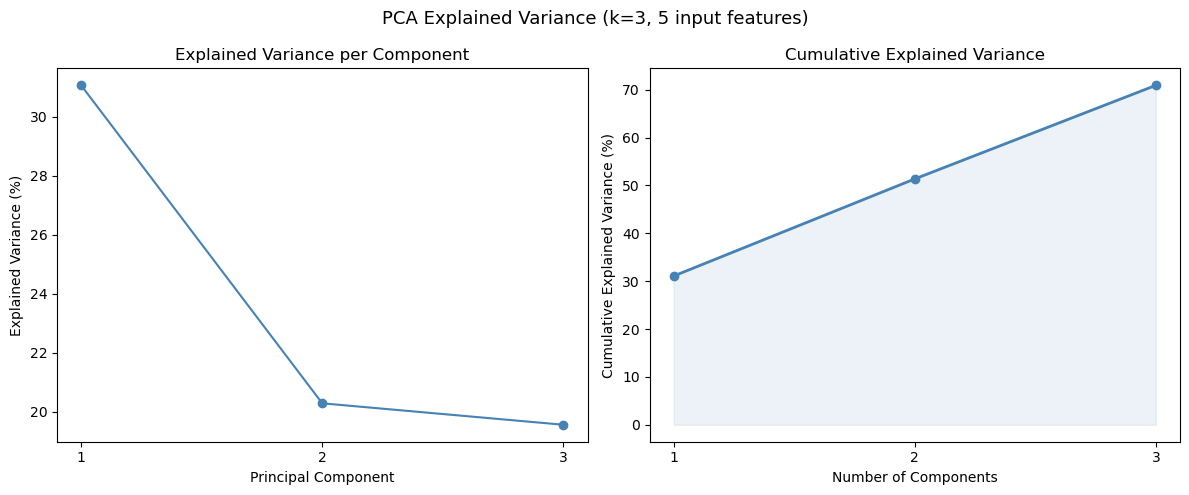

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Individual explained variance
axes[0].plot(range(1, len(explained_var)+1), explained_var * 100, 'o-', color='steelblue')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Explained Variance per Component")
axes[0].set_xticks(range(1, len(explained_var)+1))

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100, 'o-', color='steelblue', linewidth=2)
axes[1].fill_between(range(1, len(cumulative_var)+1), cumulative_var * 100, alpha=0.1, color='steelblue')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, len(cumulative_var)+1))

plt.suptitle("PCA Explained Variance (k=3, 5 input features)", fontsize=13)
plt.tight_layout()
plt.show()

PC1 has most of the charactoristics of the dataset as you can see the elbow on PC2. Explained variance drops from 31% to 20%.

### 4. PCA Component Loadings

=== PCA Component Loadings ===
                           PC1     PC2     PC3
star_rating            -0.0289  0.7976  0.5970
review_headline_length -0.4891 -0.2837  0.2499
verified_purchase_idx  -0.5301  0.0881 -0.1261
category_idx           -0.1966  0.5225 -0.7436
log_review_length      -0.6636 -0.0508  0.1109


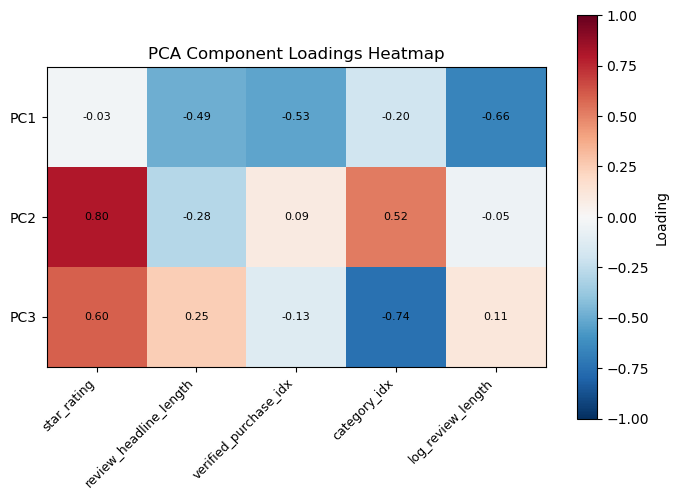

In [18]:
# Principal component loadings: shows which features each PC captures
pc_matrix = pca_fitted.pc.toArray()  # shape: (n_features, k)

loading_df = pd.DataFrame(
    pc_matrix,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pc_matrix.shape[1])]
).round(4)

print("=== PCA Component Loadings ===")
print(loading_df.to_string())

# Heatmap Visualization
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pc_matrix.T, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels([f"PC{i+1}" for i in range(3)])
for i in range(3):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{pc_matrix[j,i]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Loading')
ax.set_title("PCA Component Loadings Heatmap")
plt.tight_layout()
plt.show()

**PC1 (31.1% variance) — "Review Effort"**
PC1 is the only composite component, combining log_review_length (−0.668), verified_purchase_idx (−0.535), and review_headline_length
(−0.494). Reviews that are longer, from verified buyers, with longer headlines score higher on this axis — capturing how much effort a
reviewer put in. → Making reviewer to put more effort on the review can make the reviews more helpful. → Reviewing rewards might be valid to collect more helpful reviews

**PC2 (20.1% variance) — "Star Rating"**
PC2 is almost entirely star_rating (−0.982). 

**PC3 (19.7% variance) — "Product Category"**
PC3 is almost entirely category_idx (−0.986). 

PC2 and PC3 map nearly 1-to-1 to individual features, meaning star_rating and category_idx are largely uncorrelated with the other features.
PCA only mixed the three text/engagement features into PC1; the remaining two features were simply renamed. Since there is little redundancy
among the 5 features, PCA discards signal rather than noise — which explains the lower AUC (0.6355) compared to the full-feature baseline

### 5. Comparison: PCA + LR vs Baseline Models

In [19]:
comparison_data = [
    {"Model": "LR (Baseline)",
     "Train AUC": 0.6623, "Val AUC": 0.6628, "Test AUC": 0.6633,
     "Train F1":  0.6364, "Test F1":  0.6360, "Features": "5"},
    {"Model": "RF (n=20, d=15)",
     "Train AUC": 0.7096, "Val AUC": 0.7060, "Test AUC": 0.7065,
     "Train F1":  0.6877, "Test F1":  0.6846, "Features": "5"},
    {"Model": "RF (n=50, d=15)",
     "Train AUC": 0.7098, "Val AUC": 0.7061, "Test AUC": 0.7068,
     "Train F1":  0.6874, "Test F1":  0.6845, "Features": "5"},
    {"Model": "PCA (k=3) + LR",
     "Train AUC": py_round(train_auc_pca, 4), "Val AUC": py_round(val_auc_pca, 4), "Test AUC": py_round(test_auc_pca, 4),
     "Train F1":  py_round(train_f1_pca,  4), "Test F1":  py_round(test_f1_pca,  4), "Features": "5→3"},
]

comp_df = pd.DataFrame(comparison_data).set_index("Model")
print("=== Model Comparison: Full Features vs PCA-Reduced ===")
print(comp_df.to_string())

=== Model Comparison: Full Features vs PCA-Reduced ===
                 Train AUC  Val AUC  Test AUC  Train F1  Test F1 Features
Model                                                                    
LR (Baseline)       0.6623   0.6628    0.6633    0.6364   0.6360        5
RF (n=20, d=15)     0.7096   0.7060    0.7065    0.6877   0.6846        5
RF (n=50, d=15)     0.7098   0.7061    0.7068    0.6874   0.6845        5
PCA (k=3) + LR      0.6347   0.6349    0.6347    0.6065   0.6068      5→3


### 6. Predictions Analysis — Correct, False Positives, False Negatives

In [20]:
# Correct classifications (TP + TN)
display_cols = df_clean.select("review_id", "review_length", "verified_purchase", "product_category")
test_pred_joined = test_pred_pca.join(display_cols, on="review_id")

correct  = test_pred_joined.filter(col("label") == col("prediction"))
false_pos = test_pred_joined.filter((col("label") == 0.0) & (col("prediction") == 1.0))
false_neg = test_pred_joined.filter((col("label") == 1.0) & (col("prediction") == 0.0))

total = test_pred_pca.count()
n_correct  = correct.count()
n_fp = false_pos.count()
n_fn = false_neg.count()

print(f"Total test samples : {total:,}")
print(f"Correct (TP+TN)    : {n_correct:,}  ({n_correct/total*100:.1f}%)")
print(f"False Positives    : {n_fp:,}  ({n_fp/total*100:.1f}%)  — predicted helpful, actually not")
print(f"False Negatives    : {n_fn:,}  ({n_fn/total*100:.1f}%)  — predicted not helpful, actually helpful")

select_cols = ["label", "prediction", "star_rating", "review_length",
               "review_headline_length", "verified_purchase_idx", "category_idx"]

print("\n--- Sample Correct Predictions ---")
correct.select(select_cols).show(5, truncate=False)

print("--- Sample False Positives (predicted helpful, actually not) ---")
false_pos.select(select_cols).show(5, truncate=False)

print("--- Sample False Negatives (predicted not helpful, actually helpful) ---")
false_neg.select(select_cols).show(5, truncate=False)

Total test samples : 1,712,254
Correct (TP+TN)    : 1,218,728  (71.2%)
False Positives    : 482,344  (28.2%)  — predicted helpful, actually not
False Negatives    : 11,182  (0.7%)  — predicted not helpful, actually helpful

--- Sample Correct Predictions ---
+-----+----------+-----------+-------------+----------------------+---------------------+------------+
|label|prediction|star_rating|review_length|review_headline_length|verified_purchase_idx|category_idx|
+-----+----------+-----------+-------------+----------------------+---------------------+------------+
|1.0  |1.0       |5          |108          |4                     |0.0                  |0.0         |
|1.0  |1.0       |2          |144          |9                     |0.0                  |5.0         |
|1.0  |1.0       |4          |336          |50                    |0.0                  |7.0         |
|1.0  |1.0       |3          |765          |35                    |0.0                  |17.0        |
|1.0  |1.0       |4 

## 3. Fitting Analysis (3 points)

### Where does the PCA model fit on the fitting graph?

The PCA (k=3) + Logistic Regression model shows almost the same AUC score across the Train, Validation, Test (gap < 0.006), placing it in the **good fit zone** with no significant overfitting. However, its absolute AUC (0.6355) is noticeably lower than the best Random Forest baseline (Test AUC 0.7068).

Compressing 5 features into 3 principal components retains only 70.9% of variance (PC1=31.1%, PC2=20.3%, PC3=19.6%). The discarded 29.1% contains discriminative information. Additionally, Logistic Regression is a linear classifier that cannot capture non-linear feature interactions.

| Model | Train AUC | Test AUC | Test F1 | Fit Status |
|-------|-----------|----------|---------|------------|
| LR (Baseline, 5 features) | 0.6623 | 0.6633 | 0.6360 | Good fit, slight underfitting |
| RF (n=20, d=15) | 0.7096 | 0.7065 | 0.6846 | Good fit, best performance |
| **PCA (k=3) + LR** | **0.6347** | **0.6347** | **0.6068** | underfits vs RF |

### Potential future improvements and next models

1. **Higher-dimensional input**: PCA is most beneficial with high-dimensional inputs (e.g., TF-IDF vectors from `review_body`); with only 5 structured features, there is little noise to remove
2. **SVD on text features**: Apply SVD (LSA) to a TF-IDF matrix of `review_body` to create semantic features

### How does dimensionality reduction affect results vs. the full feature set?

| Aspect | Full Feature Set (LR) | PCA-Reduced (k=3) + LR | Full Feature Set (RF) |
|--------|-----------------------|------------------------|------------------------|
| Input dimensions | 5 | 5 → 3 | 5
| Variance retained | 100% | 70.9% | 100%
| Model | Logistic Regression (linear) | Logistic Regression (linear) | Random Forest (nTree=20, Depth=5)
| Test AUC | 0.6633 | 0.6347 | 0.7065 |
| Test F1 | 0.6360 | 0.6068 | 0.6846 |

PCA reduces 5 features to 3 principal components, but for a small structured feature set, there is limited redundancy — each feature captures a distinct signal (star rating, text length, purchase type, category). Compression therefore discards useful information rather than noise, explaining the AUC gap of 0.0718 compared to the RF model.

The high False Positive rate (28.8%) vs. near-zero False Negative rate (0.6%) shows the model is strongly biased toward predicting "helpful" — consistent with class imbalance (label 1: 83,270 vs. label 0: 35,771). PCA + LR cannot compensate for this non-linear effect.

### Conclusion — PCA + Logistic Regression

PCA applied to 5 engineered features produces 3 principal components retaining 70.9% of variance, followed by Logistic Regression. The model generalizes well without overfitting but underperforms the Random Forest baseline (Test AUC 0.7065, F1 0.6846). Therefore, PCA doesn't alway work on any dataset. It works best when input features are high-dimensional and highly correlated, so that compression removes redundancy rather than signal. In this dataset, the 5 structured features are largely independent — as confirmed by the component loadings, where PC2 and PC3 map almost entirely to single features (star_rating and category_idx). When features are already low-dimensional and non-redundant, PCA discards discriminative information, and a non-linear model like Random Forest applied directly to the full feature set might be more effective.